Libraries

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings .filterwarnings('ignore')

nltk.download('stopwords')  #"is", "the", "and", "in"


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yasha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Data Load

In [2]:
df = pd.read_csv(r'C:\Users\yasha\Downloads\spam detection\spam.csv', encoding='latin-1')

Data cleaning & EDA



In [6]:
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['label', 'message']]

print("Data load ")
print("Total messages:", len(df))

Data load 
Total messages: 5572


In [7]:
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
print("Spam and Ham count:")
print(df['label'].value_counts())            # Checking spam and ham count

Spam and Ham count:
label
ham     4825
spam     747
Name: count, dtype: int64


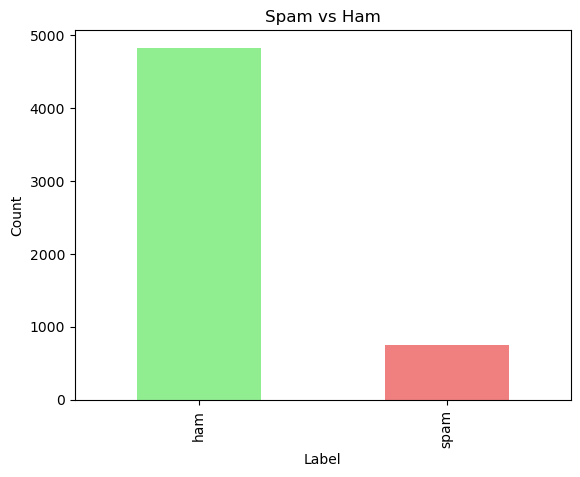

In [15]:
# Visual graph
df['label'].value_counts().plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title('Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

Text Preprocessing

In [ ]:

ps = PorterStemmer()          #convert words into roots 
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):
    text = text.lower()                            # lowercase
    text = re.sub(r'\d+', 'NUM', text)             # numbers replace
    text = re.sub(r'[^\w\s]', '', text)            # punctuation remove
    tokens = text.split()
    tokens = [ps.stem(w) for w in tokens if w not in stop_words]  # stemming + stopwords remove
    return ' '.join(tokens)

# Apply on messages
df['clean_msg'] = df['message'].apply(clean_text)

print("Preprocessing done!")
print(df[['message', 'clean_msg']].head(3))

Preprocessing done!
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   

                                           clean_msg  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri num wkli comp win fa cup final tkt ...  


TF-IDF ( Term Frequency - Inverse Document Frequency)

In [19]:
# Converting text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

X = tfidf.fit_transform(df['clean_msg'])
y = df['label'].map({'ham': 0, 'spam': 1})

print("TF-IDF done!")
print("Total features:", X.shape[1])

TF-IDF done!
Total features: 3000


In [21]:
# Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Data split done!")
print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Data split done!
Training size: 4457
Testing size: 1115


Logistic Regression


In [22]:
# Training Logistic Regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model training done!")

Model training done!


In [23]:
# Testing the model
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

Accuracy: 97.48878923766816 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.88      0.95      0.91       149

    accuracy                           0.97      1115
   macro avg       0.93      0.96      0.95      1115
weighted avg       0.98      0.97      0.98      1115



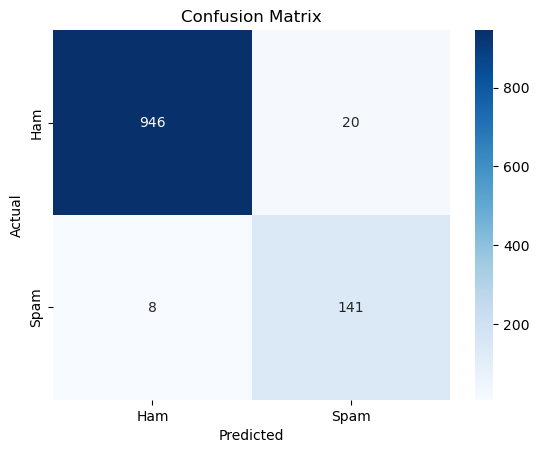

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
# Saving the model
joblib.dump(model, 'spam_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model saved successfully!")

Model saved successfully!


In [33]:
def predict_message(message):
    phishing_keywords = ['click this link', 'verify immediately', 
                         'account suspended', 'bank account', 
                         'http://', 'login now']
    
    message_lower = message.lower()
    for keyword in phishing_keywords:
        if keyword in message_lower:
            print(f"Message: '{message}'")
            print(f"Result:  SPAM ALERT!  (Phishing detected!)")
            print("-" * 50)
            return
    
    clean = clean_text(message)
    vec = tfidf.transform([clean])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]
    
    if pred == 1:
        print(f"Message: '{message}'")
        print(f"Result:  SPAM ALERT!  (Confidence: {prob:.2%})")
    else:
        print(f"Message: '{message}'")
        print(f"Result: HAM  (Confidence: {1-prob:.2%})")
    print("-" * 50)

Test Live Message 


In [34]:
# Live message test 
while True:
    message = input("Enter a message to test (type 'quit' to stop): ")
    
    if message.lower() == 'quit':
        print("Exiting...")
        break
    
    predict_message(message)

Message: 'Limited time offer! Get 70% discount on all products. Shop now and save big!'
Result: HAM  (Confidence: 60.38%)
--------------------------------------------------
Message: 'Dear customer, your bank account has been suspended. Click this link to verify immediately: http://secure-update.com'
Result:  SPAM ALERT!  (Phishing detected!)
--------------------------------------------------
Message: 'You have been selected as a lucky winner! Claim your ₹25,000 cash prize now. Call immediately!'
Result:  SPAM ALERT!  (Confidence: 87.95%)
--------------------------------------------------
Message: 'Hey, I will reach the gym by 5 PM. Let's meet there.'
Result: HAM  (Confidence: 87.22%)
--------------------------------------------------
Exiting...
